# Componente 2A: aprendizaje de la normalidad (autoencoder)

In [1]:
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from contract import save_stage_a_output, EMBEDDING_DIM, MAX_SEQ_LEN

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)


Device: mps


In [2]:
sequences = np.load("C1_output_sequences.npy")
meta = pd.read_csv("C1_output_meta.csv")
feature_names = json.load(open("C1_output_feature_names.json"))

N_FEATURES = sequences.shape[2]
assert sequences.shape[1] == MAX_SEQ_LEN
print(sequences.shape, meta.shape, N_FEATURES)


(56553, 50, 17) (56553, 4) 17


In [3]:
class SequenceDataset(Dataset):
    def __init__(self, sequences, lengths):
        self.sequences = torch.tensor(sequences, dtype=torch.float32)
        self.lengths = torch.tensor(lengths, dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx]


In [4]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, embedding_dim, max_len):
        super().__init__()
        self.max_len = max_len
        self.encoder = nn.LSTM(n_features, embedding_dim, batch_first=True)
        self.decoder = nn.LSTM(embedding_dim, embedding_dim, batch_first=True)
        self.output_layer = nn.Linear(embedding_dim, n_features)

    def encode(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.encoder(packed)
        return h_n.squeeze(0)

    def forward(self, x, lengths):
        embedding = self.encode(x, lengths)
        decoder_input = embedding.unsqueeze(1).repeat(1, self.max_len, 1)
        decoded, _ = self.decoder(decoder_input)
        reconstruction = self.output_layer(decoded)
        return reconstruction, embedding


In [5]:
def masked_mse(reconstruction, target, lengths):
    max_len = target.shape[1]
    mask = (torch.arange(max_len, device=target.device)[None, :] < lengths[:, None]).float()
    mask = mask.unsqueeze(-1)
    sq_error = (reconstruction - target) ** 2 * mask
    return sq_error.sum() / mask.sum() / target.shape[-1]

def per_sequence_error(reconstruction, target, lengths):
    max_len = target.shape[1]
    mask = (torch.arange(max_len, device=target.device)[None, :] < lengths[:, None]).float()
    mask3 = mask.unsqueeze(-1)
    sq_error = (reconstruction - target) ** 2 * mask3
    per_seq = sq_error.sum(dim=(1, 2)) / (mask.sum(dim=1) * target.shape[-1])
    return per_seq

def per_step_errors(reconstruction, target, lengths):
    max_len = target.shape[1]
    mask = (torch.arange(max_len, device=target.device)[None, :] < lengths[:, None]).float()
    step_error = ((reconstruction - target) ** 2).mean(dim=-1)
    step_error = torch.where(mask.bool(), step_error, torch.full_like(step_error, float("nan")))
    return step_error

@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    total, n = 0.0, 0
    for batch_x, batch_len in loader:
        batch_x, batch_len = batch_x.to(device), batch_len.to(device)
        recon, _ = model(batch_x, batch_len)
        loss = masked_mse(recon, batch_x, batch_len)
        total += loss.item() * len(batch_x)
        n += len(batch_x)
    return total / n


In [6]:
train_mask = (meta["split"] == "train") & (meta["label"] == 0)
train_idx = meta.index[train_mask].to_numpy()
train_ds = SequenceDataset(sequences[train_idx], meta.loc[train_idx, "seq_len"].to_numpy())
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, generator=generator)

val_normal_mask = (meta["split"] == "val") & (meta["label"] == 0)
val_normal_idx = meta.index[val_normal_mask].to_numpy()
val_normal_ds = SequenceDataset(sequences[val_normal_idx], meta.loc[val_normal_idx, "seq_len"].to_numpy())
val_normal_loader = DataLoader(val_normal_ds, batch_size=256, shuffle=False)

print("Secuencias normales de entrenamiento:", len(train_ds))
print("Secuencias normales de validación (monitor):", len(val_normal_ds))


Secuencias normales de entrenamiento: 33234
Secuencias normales de validación (monitor): 9876


In [7]:
model = LSTMAutoencoder(N_FEATURES, EMBEDDING_DIM, MAX_SEQ_LEN).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

MAX_EPOCHS = 30
PATIENCE = 3
MIN_DELTA = 1e-4

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    model.train()
    total_loss = 0.0
    for batch_x, batch_len in train_loader:
        batch_x, batch_len = batch_x.to(device), batch_len.to(device)
        optimizer.zero_grad()
        recon, _ = model(batch_x, batch_len)
        loss = masked_mse(recon, batch_x, batch_len)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_x)
    train_loss = total_loss / len(train_ds)
    val_loss = evaluate_loss(model, val_normal_loader)
    print(f"Epoch {epoch+1}/{MAX_EPOCHS} - train_loss: {train_loss:.5f} - val_loss(normal): {val_loss:.5f}")

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping en epoch {epoch+1} (sin mejora >= {MIN_DELTA} en val_loss por {PATIENCE} épocas)")
            break

model.load_state_dict(best_state)
print(f"Mejor val_loss(normal): {best_val_loss:.5f}")


Epoch 1/30 - train_loss: 0.48451 - val_loss(normal): 0.40579


Epoch 2/30 - train_loss: 0.39127 - val_loss(normal): 0.38522


Epoch 3/30 - train_loss: 0.37420 - val_loss(normal): 0.37050


Epoch 4/30 - train_loss: 0.36046 - val_loss(normal): 0.35509


Epoch 5/30 - train_loss: 0.34894 - val_loss(normal): 0.34387


...

Epoch 26/30 - train_loss: 0.25307 - val_loss(normal): 0.25271


Epoch 27/30 - train_loss: 0.25152 - val_loss(normal): 0.25201


Epoch 28/30 - train_loss: 0.24961 - val_loss(normal): 0.24868


Epoch 29/30 - train_loss: 0.24803 - val_loss(normal): 0.24773


Epoch 30/30 - train_loss: 0.24697 - val_loss(normal): 0.24717
Mejor val_loss(normal): 0.24717


In [8]:
import os
os.makedirs("stage_a_output", exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "n_features": N_FEATURES,
    "embedding_dim": EMBEDDING_DIM,
    "max_seq_len": MAX_SEQ_LEN,
    "feature_names": feature_names,
}, "stage_a_output/lstm_autoencoder.pt")


In [9]:
@torch.no_grad()
def compute_all_outputs(sequences, lengths, batch_size=256):
    model.eval()
    n = len(sequences)
    embeddings = np.zeros((n, EMBEDDING_DIM), dtype="float32")
    recon_errors = np.zeros(n, dtype="float32")
    step_errors = np.full((n, MAX_SEQ_LEN), np.nan, dtype="float32")

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_x = torch.tensor(sequences[start:end], dtype=torch.float32, device=device)
        batch_len = torch.tensor(lengths[start:end], dtype=torch.long, device=device)
        recon, emb = model(batch_x, batch_len)
        embeddings[start:end] = emb.cpu().numpy()
        recon_errors[start:end] = per_sequence_error(recon, batch_x, batch_len).cpu().numpy()
        step_errors[start:end] = per_step_errors(recon, batch_x, batch_len).cpu().numpy()

    return embeddings, recon_errors, step_errors

all_lengths = meta["seq_len"].to_numpy()
embeddings, recon_errors, step_errors = compute_all_outputs(sequences, all_lengths)
print(embeddings.shape, recon_errors.shape, step_errors.shape)


(56553, 32) (56553,) (56553, 50)


In [10]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, confusion_matrix

val_mask = meta["split"] == "val"
val_scores = recon_errors[val_mask.to_numpy()]
val_labels = meta.loc[val_mask, "label"].to_numpy()

roc_auc_val = roc_auc_score(val_labels, val_scores)
pr_auc_val = average_precision_score(val_labels, val_scores)
print("ROC-AUC (val):", round(roc_auc_val, 4))
print("PR-AUC (val):", round(pr_auc_val, 4))


ROC-AUC (val): 0.684
PR-AUC (val): 0.0239


In [11]:
precision_curve, recall_curve, thresholds = precision_recall_curve(val_labels, val_scores)
f1_scores = 2 * precision_curve * recall_curve / (precision_curve + recall_curve + 1e-9)
best_idx = np.nanargmax(f1_scores[:-1])
threshold = thresholds[best_idx]
precision_val = precision_curve[best_idx]
recall_val = recall_curve[best_idx]
f1_val = f1_scores[best_idx]
print("Umbral elegido (max F1 en val):", threshold)
print("Precision:", precision_val, "Recall:", recall_val, "F1:", f1_val)


Umbral elegido (max F1 en val): 0.401482
Precision: 0.045871559633027525 Recall: 0.08064516129032258 F1: 0.058479531701515014


In [12]:
train_normal_scores = recon_errors[train_idx]
_min, _range = train_normal_scores.min(), np.ptp(train_normal_scores)
anomaly_score = np.clip((recon_errors - _min) / (_range + 1e-9), 0.0, 1.0)

threshold_anomaly_score = float(np.clip((threshold - _min) / (_range + 1e-9), 0.0, 1.0))
print("Umbral en escala recon_error:", float(threshold))
print("Umbral equivalente en escala anomaly_score:", threshold_anomaly_score)


Umbral en escala recon_error: 0.4014819860458374
Umbral equivalente en escala anomaly_score: 0.47907236218452454


In [13]:
meta_out = pd.DataFrame({
    "sequence_id": meta["account_id"],
    "account_id": meta["account_id"],
    "split": meta["split"],
    "seq_len": meta["seq_len"],
    "label": meta["label"].astype(float),
    "recon_error": recon_errors,
    "anomaly_score": anomaly_score,
})
save_stage_a_output(meta_out, embeddings, step_errors, out_dir="stage_a_output")


Guardado en stage_a_output/: meta.csv, embeddings.npy, per_step_error.npy (56553 secuencias)


In [14]:
test_mask = meta["split"] == "test"
test_scores = recon_errors[test_mask.to_numpy()]
test_labels = meta.loc[test_mask, "label"].to_numpy()
test_preds = (test_scores >= threshold).astype(int)

roc_auc_test = roc_auc_score(test_labels, test_scores)
pr_auc_test = average_precision_score(test_labels, test_scores)
tn, fp, fn, tp = confusion_matrix(test_labels, test_preds).ravel()
precision_test = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall_test = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1_test = 2 * precision_test * recall_test / (precision_test + recall_test + 1e-9)
alert_rate_test = test_preds.mean()

print("=== Test (umbral bloqueado, sin recalibrar) ===")
print("ROC-AUC:", round(roc_auc_test, 4), "| PR-AUC:", round(pr_auc_test, 4))
print("Precision:", round(precision_test, 4), "| Recall:", round(recall_test, 4), "| F1:", round(f1_test, 4))
print("Tasa de alertas:", round(alert_rate_test, 4))
print(f"TP={tp} FP={fp} FN={fn} TN={tn}")


=== Test (umbral bloqueado, sin recalibrar) ===
ROC-AUC: 0.6446 | PR-AUC: 0.0225
Precision: 0.0437 | Recall: 0.0726 | F1: 0.0545
Tasa de alertas: 0.0206
TP=9 FP=197 FN=115 TN=9679


In [15]:
with open("etapa_a_threshold.json", "w") as f:
    json.dump({
        "threshold_recon_error": float(threshold),
        "threshold_anomaly_score": threshold_anomaly_score,
        "selection_metric": "max_f1_validation",
        "val": {
            "roc_auc": float(roc_auc_val), "pr_auc": float(pr_auc_val),
            "precision": float(precision_val), "recall": float(recall_val), "f1": float(f1_val),
        },
        "test": {
            "roc_auc": float(roc_auc_test), "pr_auc": float(pr_auc_test),
            "precision": float(precision_test), "recall": float(recall_test), "f1": float(f1_test),
            "alert_rate": float(alert_rate_test),
            "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        },
    }, f, indent=2)


### Verificación

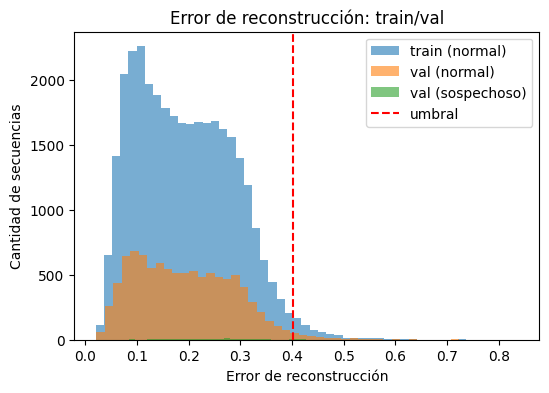

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(recon_errors[train_idx], bins=50, alpha=0.6, label="train (normal)")
plt.hist(val_scores[val_labels == 0], bins=50, alpha=0.6, label="val (normal)")
plt.hist(val_scores[val_labels == 1], bins=50, alpha=0.6, label="val (sospechoso)")
plt.axvline(threshold, color="red", linestyle="--", label="umbral")
plt.xlabel("Error de reconstrucción")
plt.ylabel("Cantidad de secuencias")
plt.legend()
plt.title("Error de reconstrucción: train/val")
plt.show()


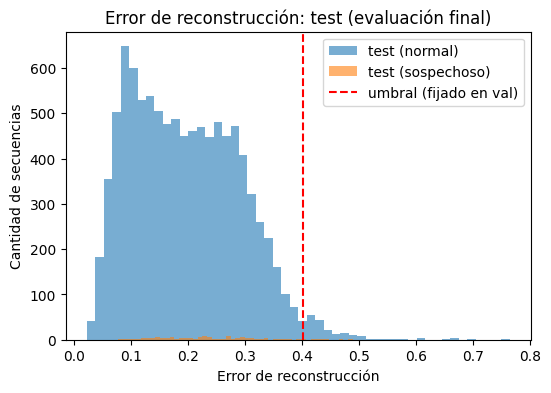

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(test_scores[test_labels == 0], bins=50, alpha=0.6, label="test (normal)")
plt.hist(test_scores[test_labels == 1], bins=50, alpha=0.6, label="test (sospechoso)")
plt.axvline(threshold, color="red", linestyle="--", label="umbral (fijado en val)")
plt.xlabel("Error de reconstrucción")
plt.ylabel("Cantidad de secuencias")
plt.legend()
plt.title("Error de reconstrucción: test (evaluación final)")
plt.show()
